# Parte 2 · Baseline con MLP

**Lo que pide el enunciado (§6) y dónde está:**

| Pide | Dónde |
|---|---|
| Construir un MLP sobre la imagen redimensionada y aplanada | `modelos.MLP` · experimentos E01, E02 |
| Definir y justificar capas, neuronas, activación, pérdida, inicialización, batch, optimizador, lr | §1 |
| Reportar train/val loss, train/val accuracy, tiempo | §3 |
| Qué información espacial se pierde al aplanar | §4 |
| Limitaciones del MLP frente a una CNN | §4 |
| Cómo afecta el tamaño de la entrada al nº de parámetros | §2 (fórmula + E01 vs E02) |

Este notebook **no entrena**: lee `resultados/E01`, `resultados/E02` (y E03 como referencia CNN).

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Definición de los experimentos

E01 es el baseline. E02 cambia **solo** la resolución de entrada, para medir el efecto del tamaño de la
entrada. E03 (una CNN, Parte 3) aparece como referencia.

In [2]:
definiciones([("E01", "(defecto)"), ("E02", "E01")])

,referencia,descripción,estado,cambios
ID,,,,
E01,(defecto),MLP 32px (baseline),terminado,modelo: resnet18 → mlp; modelo_kw: → {'res': ...
E02,E01,MLP 64px (efecto de la resolución de entrada),terminado,"modelo_kw: {'res': 32, 'ocultas': (2048, 1024)..."


| Decisión | Valor | Justificación |
|---|---|---|
| Entrada | 32×32×3 = 3 072 valores (E02: 64×64×3 = 12 288) | "razonablemente pequeña": la 1.ª capa crece con el área |
| Capas ocultas | 2 (2048 → 1024) | suficiente no linealidad; sin estructura espacial, más profundidad apenas ayuda |
| Activación | ReLU | no satura, gradiente estable |
| Normalización | BatchNorm1d tras cada capa lineal | estabiliza la optimización: queremos medir el límite del *modelo*, no la dificultad de entrenarlo |
| Salida / pérdida | 10 000 logits · entropía cruzada | clasificación multiclase |
| Inicialización | Kaiming (He) normal, sesgos a 0 | conserva la varianza de las activaciones con ReLU |
| Batch | 512 | el MLP es barato: un batch grande aprovecha la GPU |
| Optimizador / lr | Adam, 1e-3, warmup 1 época + coseno | Adam funciona bien sin ajuste fino para un baseline |
| Regularización | ninguna (sin dropout, sin wd, sin aumento) | baseline "desnudo"; early stopping (paciencia 4) |

Implementación: [modelos.py](modelos.py) clase `MLP`. La imagen llega a 128 px (el mismo pipeline que las
CNN) y el MLP la reduce a `res`×`res` con `F.interpolate` antes de aplanarla.

## 2. Tamaño de la entrada vs número de parámetros

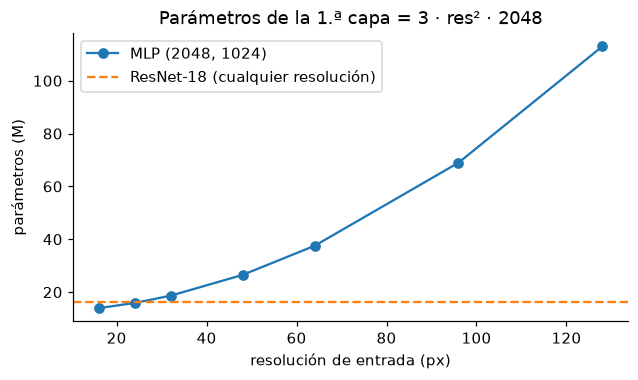

res,16,24,32,48,64,96,128
1.ª capa (M),1.6,3.5,6.3,14.2,25.2,56.6,100.7
total MLP (M),13.9,15.9,18.6,26.5,37.5,69.0,113.0


In [3]:
import torch.nn as nn
res = np.array([16, 24, 32, 48, 64, 96, 128])
primera = 3 * res**2 * 2048
p_mlp = primera + 2048 * 1024 + 1024 * 10000 + (2048 + 1024 + 10000)
p_r18 = 11.18e6 + 512 * 10000        # ResNet-18: no depende de la resolución
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(res, p_mlp / 1e6, "o-", label="MLP (2048, 1024)")
ax.axhline(p_r18 / 1e6, color="C1", ls="--", label="ResNet-18 (cualquier resolución)")
ax.set_xlabel("resolución de entrada (px)"); ax.set_ylabel("parámetros (M)"); ax.legend()
ax.set_title("Parámetros de la 1.ª capa = 3 · res² · 2048")
plt.show()
pd.DataFrame({"res": res, "1.ª capa (M)": (primera / 1e6).round(1), "total MLP (M)": (p_mlp / 1e6).round(1)}).set_index("res").T

Con 128 px (la resolución de las CNN) la primera capa tendría **100 M** de pesos, y 30 M con 64 px.
En una convolución el número de pesos depende del tamaño del filtro y de los canales, **no del tamaño de la
imagen**: una ResNet-18 tiene los mismos 16 M de parámetros a 32 px que a 512 px.

## 3. Resultados

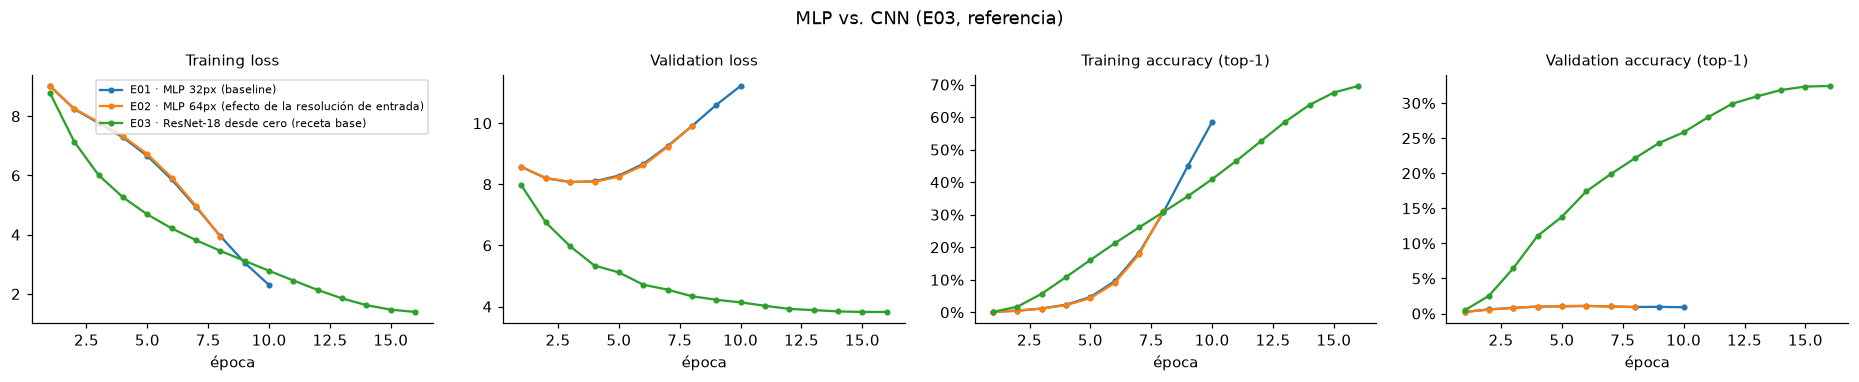

,descripción,top1,top5,f1_macro,f1_weighted,train_top1,brecha_top1,brecha_loss,mejor_ep,épocas,params_M,entrenables_M,GFLOPs,img_s,min_total,gpu
ID,,,,,,,,,,,,,,,,
E01,MLP 32px (baseline),1.1%,3.4%,0.8%,0.8%,9.6%,8.5%,2.80,6,10,18.6,18.6,0.04,34004,8,RTX A6000
E02,MLP 64px (efecto de la resolución de entrada),1.0%,3.2%,0.6%,0.6%,9.0%,8.0%,2.69,6,8,37.5,37.5,0.08,12550,5,A100 MIG 2g.10gb
E03,ResNet-18 desde cero (receta base),32.4%,54.5%,31.8%,31.8%,69.6%,37.2%,2.43,16,16,16.3,16.3,1.19,4750,27,RTX A6000


In [4]:
curvas(R, ["E01", "E02", "E03"], "MLP vs. CNN (E03, referencia)")
tabla(R, ["E01", "E02", "E03"]).style.format(FMT)

**Lectura de los resultados:**

* **El MLP casi no generaliza.** E01 llega a **1,1 % de top-1** (3,4 % top-5). Es ~100 veces el azar
  (0,01 %), pero lejísimos de cualquier CNN.
* **Sobreajuste de manual.** La *validation loss* es mínima en la época 3 y después sube, mientras la
  *training accuracy* sigue subiendo (9,6 % en la mejor época, 58,6 % en la época 10). El MLP memoriza
  las imágenes de entrenamiento en lugar de aprender rasgos que se transfieran. **Early stopping** detuvo
  E01 en la época 10 (E02 en la 8) y recuperó los pesos de la mejor época (la 6).
* **Más resolución no ayuda:** E02 duplica el lado de la imagen, **pasa de 18,6 M a 37,5 M
  parámetros** y obtiene lo mismo (1,0 %). Los píxeles extra solo dan más pesos que memorizar.
* **La arquitectura importa más que el tamaño:** E03 (ResNet-18) tiene **menos** parámetros (16,3 M) y
  logra **32,4 %**, 30 veces más. La diferencia está en el sesgo inductivo, no en la capacidad.
* **Tiempo:** el MLP es muy barato (~34 000 img/s, unos 15 s por época tras la primera). Pero ser barato
  no compensa: con una ResNet-18, 27 min rinden 30 veces más top-1.

## 4. ¿Por qué falla el MLP? Información espacial y limitaciones frente a una CNN

**Qué se pierde al aplanar.** `flatten` convierte la imagen (3, 32, 32) en un vector de 3 072 números. El
orden se conserva, pero la red **no sabe** que el valor 5 y el 6 son píxeles vecinos: para la primera
capa, permutar los píxeles de todas las imágenes de la misma forma daría exactamente el mismo problema.
Se pierden:

1. **Localidad.** Cada neurona se conecta a toda la imagen. Una CNN mira parches pequeños (3×3), donde
   está la información útil: bordes, texturas, manchas.
2. **Equivariancia a traslaciones.** Un ala desplazada 5 píxeles activa pesos distintos del MLP, que
   debe aprender el mismo patrón en cada posición por separado, con solo 50 ejemplos por especie. La
   convolución comparte los mismos pesos en todas las posiciones.
3. **Jerarquía.** Las CNN componen bordes → texturas → partes → organismo, y el *pooling* da tolerancia a
   pequeñas deformaciones. El MLP no tiene esa estructura.

**Limitaciones del MLP frente a una CNN:**

| | MLP | CNN |
|---|---|---|
| Parámetros vs. resolución | crecen con el área (3·r²·h) | independientes de la resolución |
| Compartición de pesos | ninguna | el mismo filtro en toda la imagen |
| Datos necesarios | muchos (cada posición se aprende aparte) | muchos menos (sesgo inductivo adecuado) |
| Resolución usable | obliga a reducir a 32–64 px, lo que borra detalles fine-grained | 128 px o más |
| Resultado aquí | 1,1 % top-1 | 32,4 % (ResNet-18 desde cero) |